In [161]:
import pandas as pd
import numpy as np
import math
from typing import *

day1 = pd.read_csv('observations_round_4_day_1.csv')
day2 = pd.read_csv('observations_round_4_day_2.csv')
day2['timestamp'] = day2['timestamp'] + 1000000
day3 = pd.read_csv('observations_round_4_day_3.csv')
day3['timestamp'] = day3['timestamp'] + 2000000
obs = pd.concat([day1, day2, day3], ignore_index=True)  
print(obs)
print(list(obs.columns))

       timestamp  bidPrice  askPrice  transportFees  exportTariff  \
0              0     627.0     628.5            1.0           9.0   
1            100     630.0     631.5            1.0           9.0   
2            200     630.0     631.5            1.0           9.0   
3            300     632.0     633.5            1.0           9.0   
4            400     630.5     632.0            1.0           9.0   
...          ...       ...       ...            ...           ...   
29995    2999500     797.5     799.0            1.7           9.5   
29996    2999600     801.5     803.0            1.7           9.5   
29997    2999700     804.0     805.5            1.7           9.5   
29998    2999800     798.5     800.0            1.7           9.5   
29999    2999900     797.0     798.5            1.7           9.5   

       importTariff  sugarPrice  sunlightIndex  
0              -3.0  200.000000          60.00  
1              -3.0  200.098445          60.00  
2              -3.0  200

Sugar correlation: 0.45597762961692856
Sunlight correlation: -0.5521434174532783
Correlation between sugar and sunlight: -0.4769372051521928
0.45597762961692867


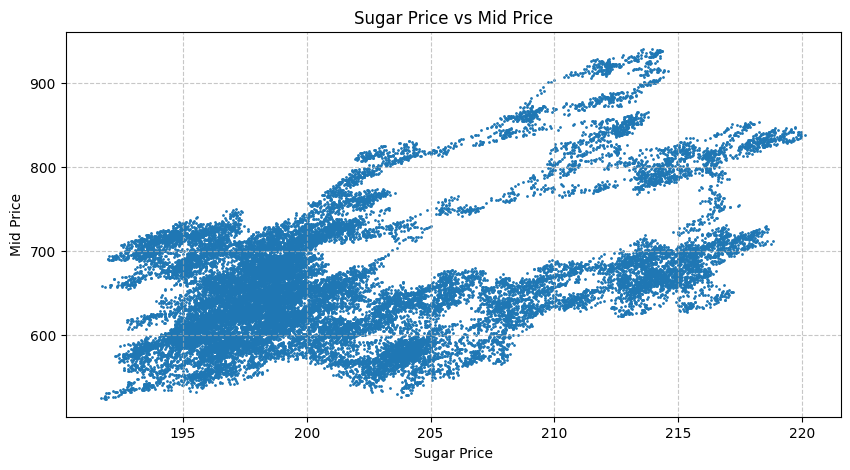

In [ ]:
import matplotlib.pyplot as plt

obs['midPrice'] = (obs['askPrice'] + obs['bidPrice']) / 2
sugar_corr = obs['midPrice'].corr(obs['sugarPrice'], method='pearson')
print(f'Sugar correlation: {sugar_corr}')
sunlight_corr = obs['midPrice'].corr(obs['sunlightIndex'], method='pearson')
print(f'Sunlight correlation: {sunlight_corr}')
sugar_sunlight_corr = obs['sugarPrice'].corr(obs['sunlightIndex'], method='pearson')
print(f'Correlation between sugar and sunlight: {sugar_sunlight_corr}')

plt.figure(figsize=(10, 5))
plt.scatter(obs['sugarPrice'], obs['midPrice'], s=1)
plt.title('Sugar Price vs Mid Price')
plt.xlabel('Sugar Price')
plt.ylabel('Mid Price')
plt.grid(True, linestyle='--', alpha=0.7)



In [223]:
from statsmodels.tsa.stattools import ccf
n_lag_list = [x for x in range(0, 500, 10)] # number of terms price lags behind sunlight
cc_dict = {}
# cross-correlation
for nlag in n_lag_list:
    cc_values = ccf(obs['sunlightIndex'], obs['midPrice'], adjusted=True, fft=True, nlags=nlag)
    cc_dict[nlag] = cc_values.mean()
print(cc_dict)
print(sorted(cc_dict, key=cc_dict.get))

{0: np.float64(nan), 10: np.float64(-0.5520057960778326), 20: np.float64(-0.5518362844549878), 30: np.float64(-0.5516497086509414), 40: np.float64(-0.5514466314117725), 50: np.float64(-0.5512276766197457), 60: np.float64(-0.5509930376522949), 70: np.float64(-0.5507425584226133), 80: np.float64(-0.5504756757528142), 90: np.float64(-0.5501920433713399), 100: np.float64(-0.5498917356763823), 110: np.float64(-0.5495751895686247), 120: np.float64(-0.5492428033594466), 130: np.float64(-0.5488950157893718), 140: np.float64(-0.5485321224514251), 150: np.float64(-0.548154498610346), 160: np.float64(-0.5477624369266441), 170: np.float64(-0.547356202672532), 180: np.float64(-0.546936014375356), 190: np.float64(-0.546501886072674), 200: np.float64(-0.5460537315207626), 210: np.float64(-0.5455914903483648), 220: np.float64(-0.5451151907193783), 230: np.float64(-0.544624888485107), 240: np.float64(-0.5441206286201116), 250: np.float64(-0.5436023949701523), 260: np.float64(-0.5430701922763931), 270: 

C:\Users\Sean\AppData\Local\Temp\ipykernel_16280\3886542155.py:7: RuntimeWarning: Mean of empty slice.
  cc_dict[nlag] = cc_values.mean()


{-500: np.float64(0.498751431101954), -300: np.float64(0.540673700299934), -100: np.float64(0.555917149966001), 100: np.float64(0.5520433514212678), 300: np.float64(0.5443414445315071), 500: np.float64(0.5347682602738917)}
663.637525
74.5451292886915


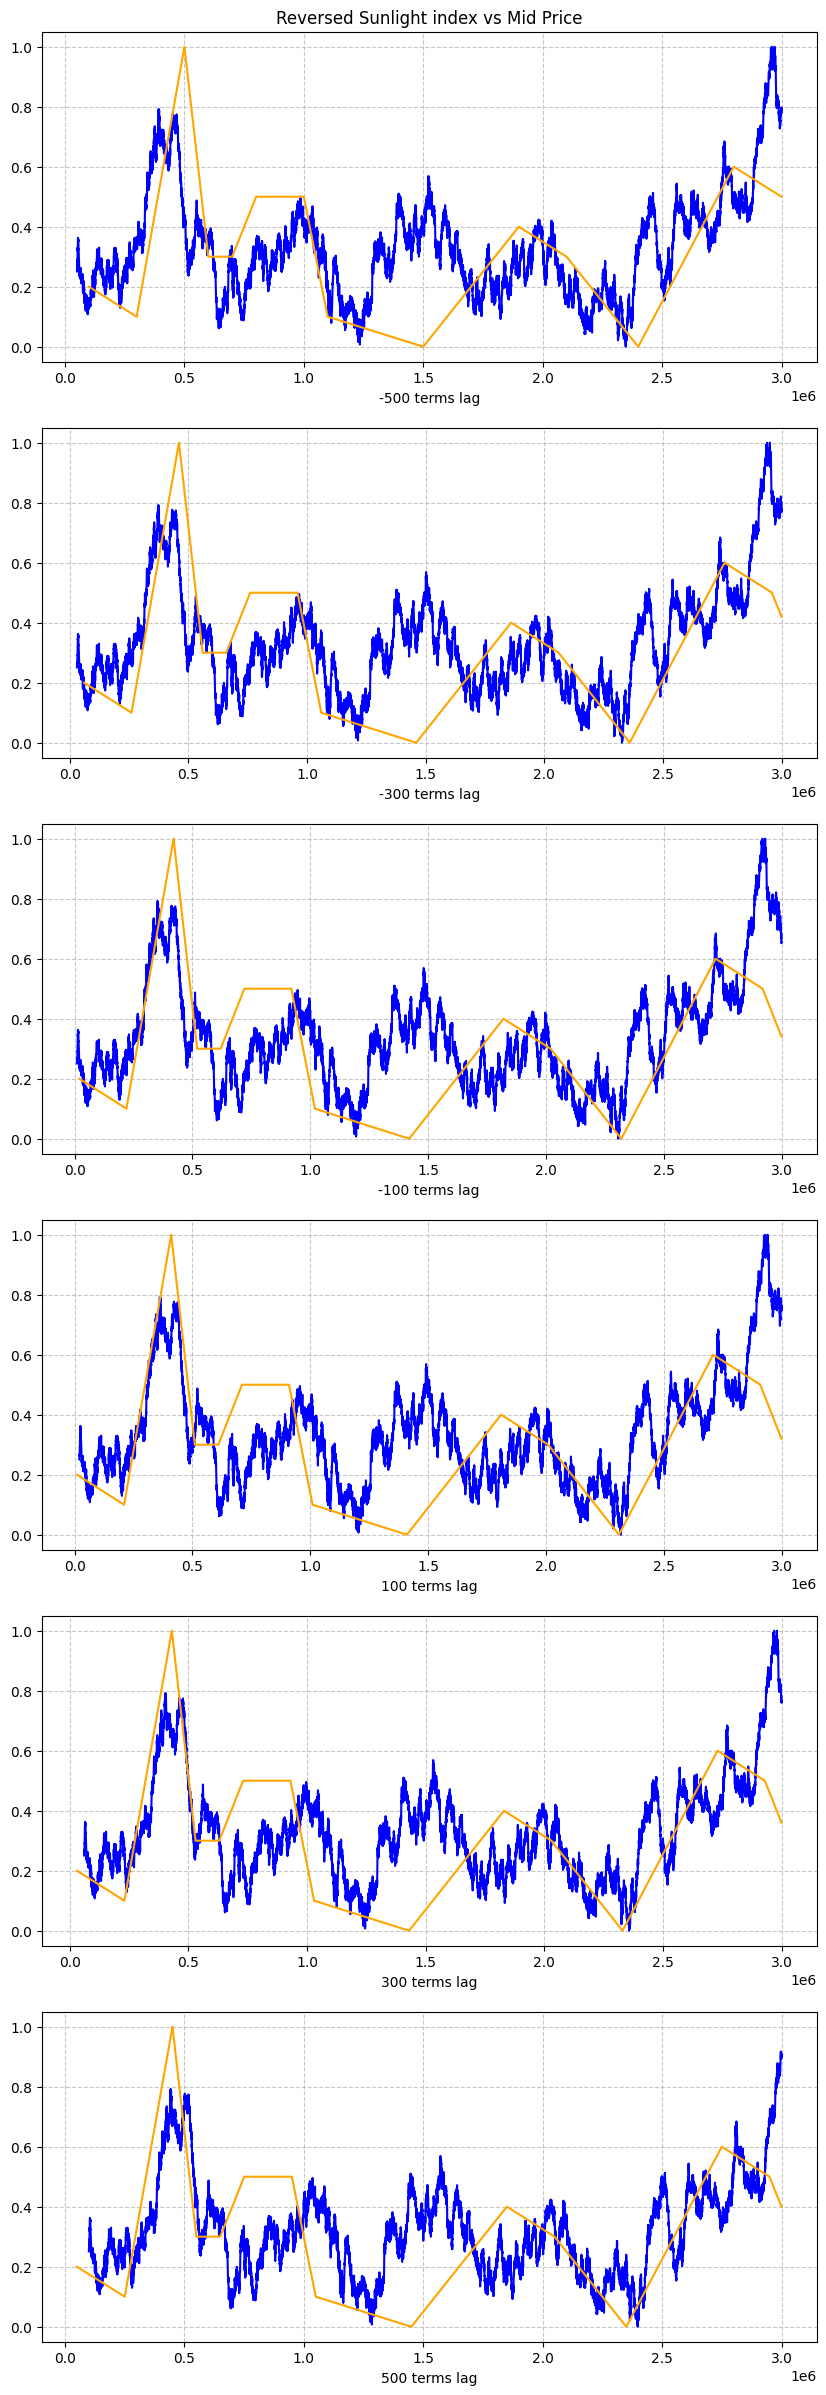

In [224]:
n_lag_list2 = [x for x in range(-500, 600, 200)] # number of terms price lags behind sunlight
#n_lag_list2 = [-1000, 1000] # number of terms price lags behind sunlight
norm_price = (obs['midPrice'] - obs['midPrice'].min()) / (obs['midPrice'].max() - obs['midPrice'].min())
reversed_norm_sunlight = 1 - (obs['sunlightIndex'] - obs['sunlightIndex'].min()) / (obs['sunlightIndex'].max() - obs['sunlightIndex'].min())
plt.figure(figsize=(10, 5 * len(n_lag_list2)))
plt.axis('off')
plt.title('Reversed Sunlight index vs Mid Price')
#plt.scatter(trunc_sunlight, trunc_price, s=1)
'''for n_lag in n_lag_list2:
    plt.subplot(len(n_lag_list2), 1, n_lag_list2.index(n_lag) + 1)
    if n_lag < 0:
        plt.plot(obs['timestamp'], norm_price, color='blue')
        plt.plot(obs['timestamp'] + (-n_lag * 100), reversed_norm_sunlight, color='orange')
    else:
        plt.plot(obs['timestamp'] + (n_lag * 100), norm_price, color='blue')
        plt.plot(obs['timestamp'], reversed_norm_sunlight, color='orange')
    plt.xlabel(f'{n_lag} terms lag')'''

# the time series below have the same timestamps, easier for correlation analysis
corr_dict = {}
for n_lag in n_lag_list2:
    plt.subplot(len(n_lag_list2), 1, n_lag_list2.index(n_lag) + 1)
    if n_lag < 0:
        plt.plot(obs['timestamp'][-n_lag:], norm_price[:n_lag], color='blue')
        plt.plot(obs['timestamp'][-n_lag:], reversed_norm_sunlight.shift(periods=-n_lag)[:n_lag], color='orange')
        corr_dict[n_lag] = norm_price[:n_lag].corr(reversed_norm_sunlight.shift(periods=-n_lag)[:n_lag], method='pearson')
    else:
        if n_lag == 0:
            n_lag = 1
        plt.plot(obs['timestamp'][n_lag:], norm_price.shift(periods=n_lag)[:-n_lag], color='blue')
        plt.plot(obs['timestamp'][n_lag:], reversed_norm_sunlight[:-n_lag], color='orange')
        corr_dict[n_lag] = norm_price.shift(periods=n_lag)[:-n_lag].corr(reversed_norm_sunlight[:-n_lag], method='pearson')
    plt.xlabel(f'{n_lag} terms lag')
    plt.grid(True, linestyle='--', alpha=0.7)

print(corr_dict)
print(obs['midPrice'].mean())
print(obs['midPrice'].std())

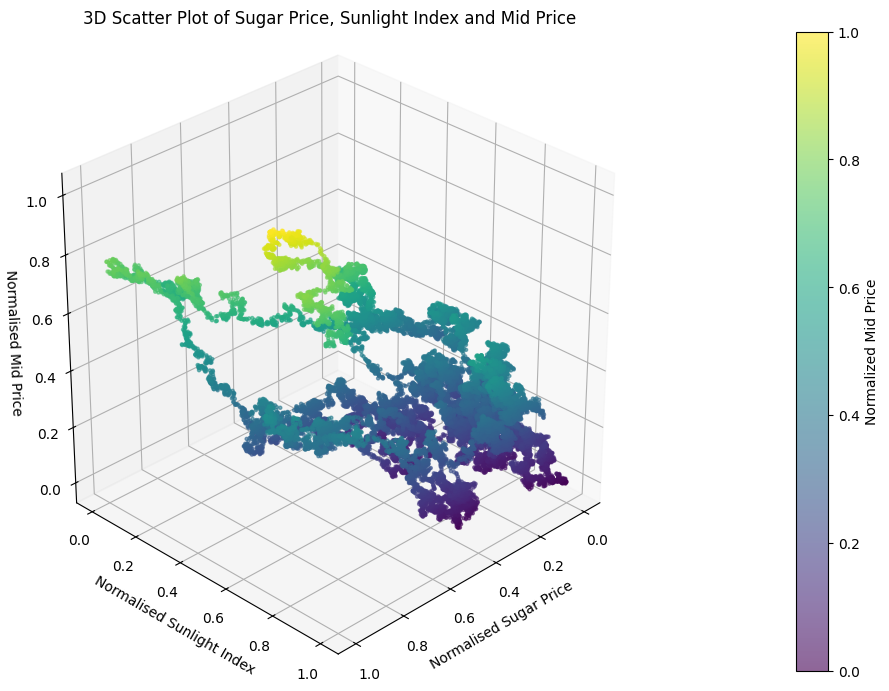

In [164]:
# 3d plot of sugar price, sunlight index and mid price (not lagged)
# code adapted from https://matplotlib.org/stable/gallery/mplot3d/scatter3d.html
fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(projection='3d')

# normalise x,y,z to [0,1]
x = (obs['sugarPrice'] - obs['sugarPrice'].min()) / (obs['sugarPrice'].max() - obs['sugarPrice'].min())
y = (obs['sunlightIndex'] - obs['sunlightIndex'].min()) / (obs['sunlightIndex'].max() - obs['sunlightIndex'].min())
z = (obs['midPrice'] - obs['midPrice'].min()) / (obs['midPrice'].max() - obs['midPrice'].min())
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=5, alpha=0.6)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Normalized Mid Price')
ax.grid(True)
ax.set_box_aspect([1,1,1])  # aspect ratio is 1:1:1
ax.view_init(elev=30, azim=45)
ax.set_xlabel('Normalised Sugar Price')
ax.set_ylabel('Normalised Sunlight Index')
ax.set_zlabel('Normalised Mid Price')
ax.set_title('3D Scatter Plot of Sugar Price, Sunlight Index and Mid Price')

plt.tight_layout()
plt.show()

20.0 70.0
{'20 - 27': np.float64(810.5851883561644), '28 - 35': np.float64(792.8844178082192), '36 - 43': np.float64(732.9030029476787), '44 - 51': np.float64(686.398470991712), '52 - 59': np.float64(647.1646708635554), '60 - 67': np.float64(627.4601663383672), '68 - 75': np.float64(642.101308411215)}
['20 - 27', '28 - 35', '36 - 43', '44 - 51', '52 - 59', '68 - 75', '60 - 67']


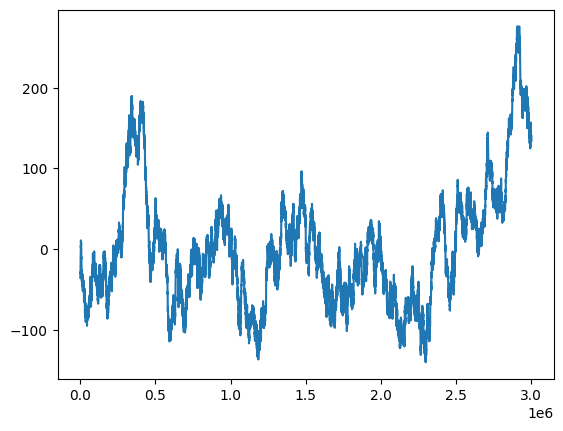

In [165]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
print(min(obs['sunlightIndex']), max(obs['sunlightIndex']))
ccsi_list = [x for x in range(20, 70, 1)]
corr_dict = {}
mean_dict = {}

for ccsi in ccsi_list:
    obs_csi = obs.loc[obs['sunlightIndex'] > ccsi]
    corr_dict[ccsi] = obs_csi['midPrice'].corr(obs_csi['sunlightIndex'], method='pearson')
    mean_dict[ccsi] = obs_csi['midPrice'].mean()

region_size = 8
ccsi_regions_list = [x for x in range(20, 70, region_size)]
mean_regions_dict = {}
for ccsi_region in ccsi_regions_list:
    region_name = f"{ccsi_region} - {ccsi_region + region_size - 1}"
    obs_csi_regions = obs.loc[(obs['sunlightIndex'] >= ccsi_region) & (obs['sunlightIndex'] < ccsi_region + region_size)]
    mean_regions_dict[region_name] = obs_csi_regions['midPrice'].mean()

# print(mean_dict)
# print(corr_dict)
# print(sorted(mean_dict, key=mean_dict.get))
print(mean_regions_dict)
print(sorted(mean_regions_dict, key=mean_regions_dict.get, reverse=True))

pca = PCA(n_components=1)
sugar_macaron = pca.fit_transform(obs[['sugarPrice', 'midPrice']])
plt.plot(obs['timestamp'], sugar_macaron, label=f'test')
# plt.plot(obs['timestamp'], obs['sugarPrice'], label='Sugar Price')
# plt.plot(obs['timestamp'], obs['midPrice'], label='Mid Price')
# plt.plot(obs['timestamp'], obs['sunlightIndex'] > 42, label='Sunlight Index')
